# TabICL Survival: Sklearn-Style Wrapper Demo

This notebook demonstrates how to use `TabICLSurvivalEstimator`, the sklearn-style wrapper around a trained in-context-learning survival checkpoint.

It covers:

1. The survival data format expected by the wrapper.
2. How to fit the in-context prompt and make predictions.
3. How to compare the estimated survival curve with a known true survival curve for a single unit.

The example uses a synthetic Weibull proportional-hazards dataset because its true survival function is known exactly.

## 1. Setup

The default checkpoint path below points to the Stage 1 winner stored in the project-level `checkpoints/` directory. If you move the checkpoint, update `CHECKPOINT_PATH`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from tabicl.survival import TabICLSurvivalEstimator

PROJECT_ROOT = REPO_ROOT.parent
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "step-5000.ckpt"
print(CHECKPOINT_PATH)
assert CHECKPOINT_PATH.is_file(), f"Checkpoint not found: {CHECKPOINT_PATH}"

/Users/q24tian/Library/CloudStorage/GoogleDrive-qltian2021@gmail.com/Other computers/My Laptop/Documents/Research/ai/survival_icl/checkpoints/step-5000.ckpt


## 2. Survival Data Format

For a tabular survival dataset we need:

- `X`: covariates, shape `(n_samples, n_features)`. This can be a NumPy array or a pandas DataFrame.
- `t_obs`: observed time, shape `(n_samples,)`, strictly positive. This is `min(T_event, T_censor)`.
- `delta`: event indicator, shape `(n_samples,)`. Use `1` when the event is observed and `0` when the row is right-censored.

The wrapper accepts survival outcomes either as separate `t=` and `delta=` arguments or as a two-column array/dict passed as `y`.

In [2]:
def make_weibull_ph_data(n=768, p=5, seed=20260607):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p)).astype(np.float32)
    beta = np.array([0.8, -0.6, 0.45, 0.0, 0.25], dtype=np.float32)[:p]
    eta = X @ beta

    shape = 1.6
    scale = 10.0
    u = rng.uniform(size=n)
    t_event = scale * (-np.log(u) / np.exp(eta)) ** (1.0 / shape)

    censor_time = rng.exponential(scale=18.0, size=n)
    t_obs = np.minimum(t_event, censor_time).astype(np.float32)
    delta = (t_event <= censor_time).astype(np.float32)

    columns = [f"x{j}" for j in range(p)]
    X_df = pd.DataFrame(X, columns=columns)

    params = {"beta": beta, "shape": shape, "scale": scale}
    return X_df, t_obs, delta, t_event.astype(np.float32), params


def true_survival_weibull_ph(times, x, params):
    beta = params["beta"]
    shape = params["shape"]
    scale = params["scale"]
    eta = np.asarray(x, dtype=np.float32) @ beta
    return np.exp(-np.exp(eta) * (times / scale) ** shape)


X, t_obs, delta, t_event, true_params = make_weibull_ph_data()

print("X format:")
display(X.head())
print(f"X shape: {X.shape}")
print(f"t_obs shape: {t_obs.shape}; first five: {t_obs[:5]}")
print(f"delta shape: {delta.shape}; first five: {delta[:5]}")
print(f"Event rate: {delta.mean():.3f}")

X format:


,x0,x1,x2,x3,x4
0,0.820695,-1.307379,-0.934348,0.266948,0.572358
1,-1.181714,0.576850,-1.639539,0.056557,0.117260
2,1.269135,0.279096,-0.747255,0.349117,0.376461
3,0.066844,2.364362,-1.064346,0.322262,0.293386
4,-0.089506,0.093481,0.831148,0.092971,0.999145


X shape: (768, 5)
t_obs shape: (768,); first five: [ 2.156979  29.801437   2.3658352 12.271058   6.9820538]
delta shape: (768,); first five: [1. 0. 1. 0. 1.]
Event rate: 0.626


Split the data into an in-context support set and query rows. The support set is the prompt used by TabICL. Query outcomes are not passed to the model; they are used only here for demonstration.

In [3]:
n_context = 512

X_context = X.iloc[:n_context]
t_context = t_obs[:n_context]
delta_context = delta[:n_context]

X_query = X.iloc[n_context:]
t_query_obs = t_obs[n_context:]
delta_query = delta[n_context:]
t_query_event = t_event[n_context:]

print(X_context.shape, t_context.shape, delta_context.shape)
print(X_query.shape)

(512, 5) (512,) (512,)
(256, 5)


## 3. Fit the Sklearn-Style Wrapper

`fit` does not train neural-network weights. It stores and preprocesses the in-context support set. Internally:

- Features are converted to numeric values.
- Feature standardization is fit on support rows only.
- Survival-time scaling is fit on support `(t_obs, delta)` only at inference time.
- Outputs are mapped back to raw time units.

In [4]:
estimator = TabICLSurvivalEstimator(
    checkpoint_path=CHECKPOINT_PATH,
    device="cpu",
    max_context_size=512,
    query_batch_size=64,
)

estimator.fit(X_context, t=t_context, delta=delta_context)
estimator

,checkpoint_path,PosixPath('/U...ep-5000.ckpt')
,device,'cpu'
,max_context_size,512
,query_batch_size,64
,standardize_features,True
,random_state,42
,verbose,False


You can also pass the survival target as a two-column array with columns `[time, delta]`:

```python
y_context = np.column_stack([t_context, delta_context])
estimator.fit(X_context, y_context)
```

or as a dictionary:

```python
estimator.fit(X_context, {"time": t_context, "event": delta_context})
```

## 4. Unconditional Prediction: `S(t | X)`

Pick one query unit and estimate its survival function from features alone.

In [5]:
query_idx = 0
x_one = X_query.iloc[[query_idx]]
x_one_raw = x_one.iloc[0].to_numpy(dtype=np.float32)

time_grid = np.linspace(0.25, 35.0, 150, dtype=np.float32)
true_surv = true_survival_weibull_ph(time_grid, x_one_raw, true_params)
estimated_surv = estimator.predict_survival_function(x_one, times=time_grid)[0]

print(f"Observed query time: {t_query_obs[query_idx]:.3f}")
print(f"Event observed: {bool(delta_query[query_idx])}")
print(f"True event time: {t_query_event[query_idx]:.3f}")
print(f"Predicted median event time: {estimator.predict(x_one)[0]:.3f}")

Observed query time: 4.106
Event observed: True
True event time: 4.106
Predicted median event time: 4.356


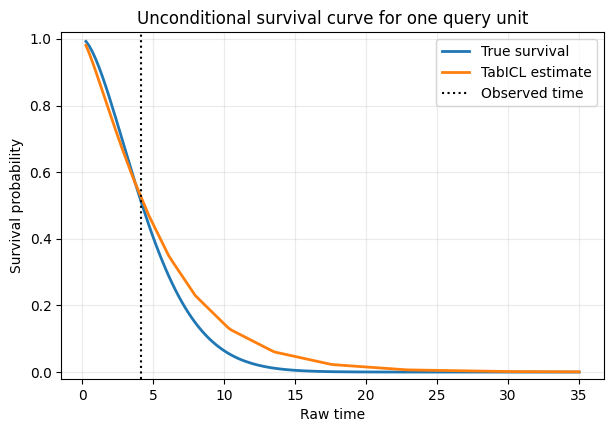

In [6]:
plt.figure(figsize=(7, 4.5))
plt.plot(time_grid, true_surv, label="True survival", linewidth=2)
plt.plot(time_grid, estimated_surv, label="TabICL estimate", linewidth=2)
plt.axvline(t_query_obs[query_idx], color="black", linestyle=":", label="Observed time")
plt.ylim(-0.02, 1.02)
plt.xlabel("Raw time")
plt.ylabel("Survival probability")
plt.title("Unconditional survival curve for one query unit")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 5. Conditional Prediction After Censoring: `S(t | T > c, X)`

If a unit is known to be event-free up to a censoring/landmark time `c`, the conditional survival curve is:

\[
S(t \mid T > c, X) = \begin{cases}
1, & t \le c \\
S(t \mid X) / S(c \mid X), & t > c.
\end{cases}
\]

The wrapper applies this as post-model conditioning. The query censoring time is not passed into the TabICL prompt.

In [7]:
censored_positions = np.flatnonzero(delta_query == 0)
assert censored_positions.size > 0, "Synthetic split happened to contain no censored query rows."

cond_idx = int(censored_positions[0])
x_censored = X_query.iloc[[cond_idx]]
x_censored_raw = x_censored.iloc[0].to_numpy(dtype=np.float32)
c = float(t_query_obs[cond_idx])

true_unconditional = true_survival_weibull_ph(time_grid, x_censored_raw, true_params)
s_c = float(true_survival_weibull_ph(np.array([c], dtype=np.float32), x_censored_raw, true_params)[0])
true_conditional = np.where(time_grid <= c, 1.0, true_unconditional / max(s_c, 1e-8))
true_conditional = np.clip(true_conditional, 0.0, 1.0)

estimated_conditional = estimator.predict_survival_function(
    x_censored,
    times=time_grid,
    conditional_time=np.array([c], dtype=np.float32),
)[0]

print(f"Censored query row: {cond_idx}")
print(f"Censoring/landmark time c: {c:.3f}")
print(f"Privileged true event time, for demo only: {t_query_event[cond_idx]:.3f}")

Censored query row: 6
Censoring/landmark time c: 25.018
Privileged true event time, for demo only: 32.878


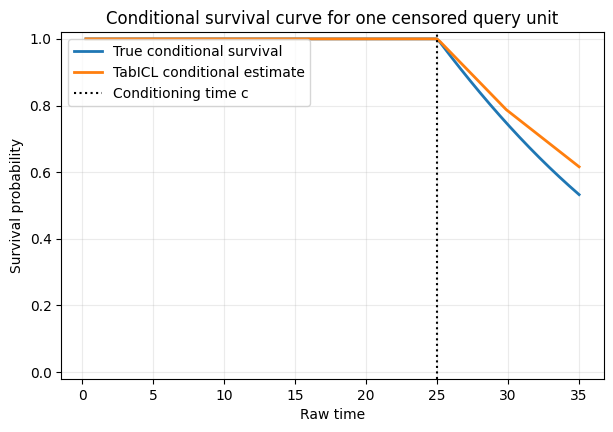

In [8]:
plt.figure(figsize=(7, 4.5))
plt.plot(time_grid, true_conditional, label="True conditional survival", linewidth=2)
plt.plot(time_grid, estimated_conditional, label="TabICL conditional estimate", linewidth=2)
plt.axvline(c, color="black", linestyle=":", label="Conditioning time c")
plt.ylim(-0.02, 1.02)
plt.xlabel("Raw time")
plt.ylabel("Survival probability")
plt.title("Conditional survival curve for one censored query unit")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 6. Quantiles and Median Prediction

`predict` returns the median event time. `predict_quantiles` returns raw-time event quantiles.

In [9]:
quantile_levels = (0.1, 0.25, 0.5, 0.75, 0.9)
quantiles = estimator.predict_quantiles(x_one, quantile_levels=quantile_levels)[0]

pd.DataFrame({
    "quantile_level": quantile_levels,
    "predicted_raw_time": quantiles,
})

,quantile_level,predicted_raw_time
0,0.10,0.963043
1,0.25,2.143643
2,0.50,4.355985
3,0.75,7.595953
4,0.90,11.594856
